In [1]:
import sys
print(sys.executable)

C:\venvs\guardianshield-clv\Scripts\python.exe


# Engagement 2 — RFM Analysis

**Client:** GuardianShield Insurance (fictional)
**Engagement:** Customer Lifetime Value Prediction
**Notebook:** 01 — RFM Segmentation
**Author:** [Your Name]
**Date:** [Today's date]

## Purpose

Compute Recency, Frequency, and Monetary (RFM) metrics per customer to:

1. Establish a behavioural foundation for CLV modelling
2. Segment the customer base into actionable groups
3. Validate against the ground-truth segments used during data generation

## Data version

Uses **v2 synthetic data** — segments differ in premium, renewal behaviour, and maximum tenure. This produces clean separation across all three RFM dimensions.

In [2]:
# ============================================
# SETUP
# ============================================

import sys
from pathlib import Path

# Make src/ importable from the notebook
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

from config import DB_URL, DB_SCHEMA, IMAGES_DIR

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Database connection
engine = create_engine(DB_URL)

with engine.connect() as conn:
    version = conn.execute(text("SELECT version();")).scalar()
    print(f"Connected to Postgres")
    print(f"Schema: {DB_SCHEMA}")
    print(f"Server: {version[:60]}...")

print(f"\nPython executable: {sys.executable}")

Connected to Postgres
Schema: clv
Server: PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35...

Python executable: C:\venvs\guardianshield-clv\Scripts\python.exe


In [3]:
# ============================================
# LOAD DATA
# ============================================

customers = pd.read_sql(
    f"SELECT * FROM {DB_SCHEMA}.customers",
    engine,
    parse_dates=["policy_start_date", "churned_date"],
)

transactions = pd.read_sql(
    f"SELECT * FROM {DB_SCHEMA}.transactions",
    engine,
    parse_dates=["transaction_date"],
)

print(f"Customers:     {len(customers):,}")
print(f"Transactions:  {len(transactions):,}")
print(f"\nTransaction date range:")
print(f"  From: {transactions['transaction_date'].min().date()}")
print(f"  To:   {transactions['transaction_date'].max().date()}")

transactions.head()

Customers:     5,000
Transactions:  107,884

Transaction date range:
  From: 2020-06-29
  To:   2025-12-28


,customer_id,policy_id,transaction_id,transaction_date,premium_amount,tenure_months,claims_count,renewed
0,GS-000001,POL-000001-01,TXN-000001-0000,2022-11-06,62.10,0,0,False
1,GS-000001,POL-000001-01,TXN-000001-0001,2022-12-06,61.92,1,0,False
2,GS-000001,POL-000001-01,TXN-000001-0002,2023-01-06,64.10,2,0,False
3,GS-000001,POL-000001-01,TXN-000001-0003,2023-02-06,62.61,3,0,False
4,GS-000001,POL-000001-01,TXN-000001-0004,2023-03-06,61.63,4,0,False


In [4]:
# ============================================
# SNAPSHOT DATE
# ============================================
# RFM needs a fixed reference point for "recency".
# Standard practice: one day after the last observed transaction.

snapshot_date = transactions["transaction_date"].max() + pd.Timedelta(days=1)

print(f"Snapshot date: {snapshot_date.date()}")
print(f"\nInterpretation: recency is measured as days between")
print(f"each customer's last transaction and {snapshot_date.date()}.")

Snapshot date: 2025-12-29

Interpretation: recency is measured as days between
each customer's last transaction and 2025-12-29.


In [5]:
# ============================================
# COMPUTE RFM
# ============================================
# Frequency has two competing definitions:
#   - Frequency (transactions): raw count — biased by payment cadence
#   - Frequency (renewals):     count of renewal events — true loyalty signal
# We compute both and compare.

# Recency — days since last transaction
recency = (
    transactions
    .groupby("customer_id")["transaction_date"]
    .max()
    .rename("recency_days")
    .to_frame()
)
recency["recency_days"] = (snapshot_date - recency["recency_days"]).dt.days

# Frequency (transactions) — count of every payment
freq_tx = (
    transactions
    .groupby("customer_id")["transaction_id"]
    .count()
    .rename("frequency_tx")
)

# Frequency (renewals) — count of renewal events
freq_renewal = (
    transactions
    .query("renewed == True")
    .groupby("customer_id")["transaction_id"]
    .count()
    .rename("frequency_renewal")
)

# Monetary — total premium paid
monetary = (
    transactions
    .groupby("customer_id")["premium_amount"]
    .sum()
    .round(2)
    .rename("monetary_total")
)

# Combine into one RFM table
rfm = (
    recency
    .join(freq_tx)
    .join(freq_renewal)
    .join(monetary)
    .fillna({"frequency_renewal": 0})
)

# Add policy metadata from customers table
rfm = rfm.join(
    customers.set_index("customer_id")[
        ["segment", "policy_type", "payment_frequency", "churned", "policy_start_date"]
    ]
)

rfm["frequency_renewal"] = rfm["frequency_renewal"].astype(int)

print(f"RFM table built for {len(rfm):,} customers.")
print(f"\nSample:")
rfm.head(10)

RFM table built for 5,000 customers.

Sample:


,recency_days,frequency_tx,frequency_renewal,monetary_total,segment,policy_type,payment_frequency,churned,policy_start_date
customer_id,,,,,,,,,
GS-000001,84,36,2,2284.54,standard,Home,Monthly,True,2022-11-06
GS-000002,15,35,2,881.30,price_sensitive,Motor,Monthly,False,2023-02-14
GS-000003,3,2,0,201.04,loyal,Travel,Monthly,True,2025-11-26
GS-000004,341,5,4,3575.33,standard,Home,Annual,False,2021-01-22
GS-000005,1275,12,0,528.74,price_sensitive,Home,Monthly,True,2021-08-03
GS-000006,14,48,3,1905.96,standard,Home,Monthly,False,2022-01-15
GS-000007,20,57,4,4727.33,loyal,Motor,Monthly,False,2021-04-09
GS-000008,118,48,3,3356.38,standard,Home,Monthly,True,2021-10-02
GS-000009,571,48,3,1393.92,price_sensitive,Motor,Monthly,True,2020-07-06


In [6]:
# ============================================
# SUMMARY STATISTICS
# ============================================

summary = rfm[[
    "recency_days", "frequency_tx", "frequency_renewal", "monetary_total"
]].describe().round(2)

print("RFM Summary Statistics")
print("=" * 70)
print(summary)

RFM Summary Statistics
       recency_days  frequency_tx  frequency_renewal  monetary_total
count       5000.00       5000.00            5000.00         5000.00
mean         249.07         21.58               1.69         1768.47
std          411.67         18.92               1.56         1532.35
min            1.00          1.00               0.00           30.74
25%           11.75          5.00               0.00          620.22
50%           25.00         13.00               1.00         1296.68
75%          307.25         36.00               3.00         2494.89
max         1999.00         67.00               5.00        12163.52


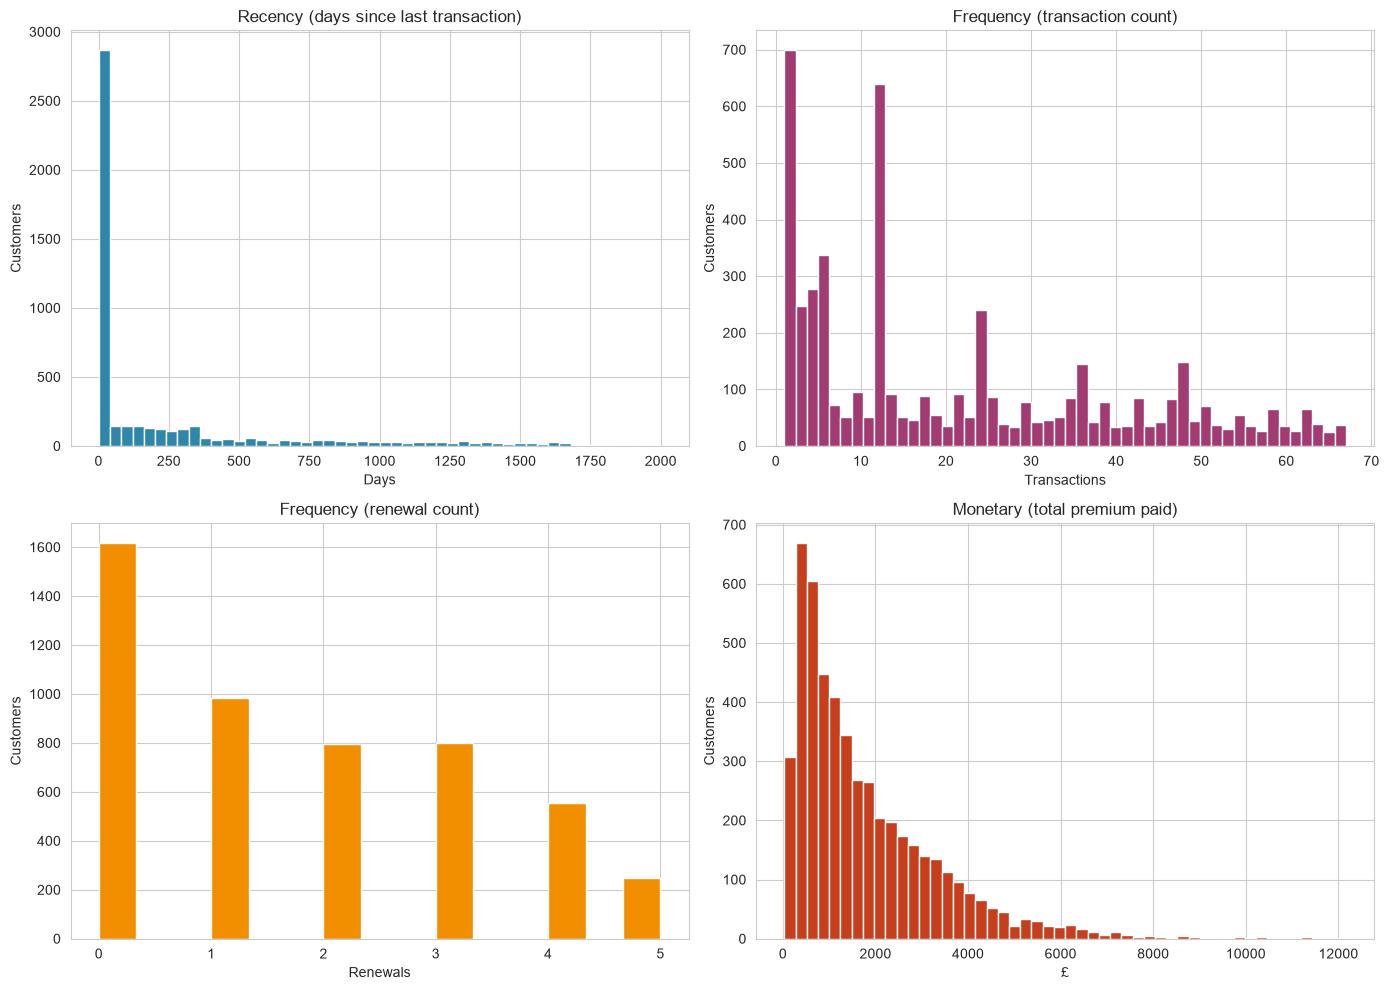

Saved: C:\Users\adebi\OneDrive\Desktop\DataScienceConsultingPortfolio\01_Portfolio-Projects\OkYeahInsight-Analytics\GuardianShield-Insurance\Engagement-2-Customer-Lifetime-Value\images\rfm_distributions.png


In [7]:
# ============================================
# DISTRIBUTIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(rfm["recency_days"], bins=50, color="#2E86AB", edgecolor="white")
axes[0, 0].set_title("Recency (days since last transaction)")
axes[0, 0].set_xlabel("Days")
axes[0, 0].set_ylabel("Customers")

axes[0, 1].hist(rfm["frequency_tx"], bins=50, color="#A23B72", edgecolor="white")
axes[0, 1].set_title("Frequency (transaction count)")
axes[0, 1].set_xlabel("Transactions")
axes[0, 1].set_ylabel("Customers")

axes[1, 0].hist(rfm["frequency_renewal"], bins=15, color="#F18F01", edgecolor="white")
axes[1, 0].set_title("Frequency (renewal count)")
axes[1, 0].set_xlabel("Renewals")
axes[1, 0].set_ylabel("Customers")

axes[1, 1].hist(rfm["monetary_total"], bins=50, color="#C73E1D", edgecolor="white")
axes[1, 1].set_title("Monetary (total premium paid)")
axes[1, 1].set_xlabel("£")
axes[1, 1].set_ylabel("Customers")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "rfm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {IMAGES_DIR / 'rfm_distributions.png'}")

In [8]:
# ============================================
# RFM SCORING (1-5 scale)
# ============================================
# Each dimension is split into quintiles.
# Recency is INVERTED: smaller days = better = higher score.

rfm["r_score"] = pd.qcut(
    rfm["recency_days"],
    q=5,
    labels=[5, 4, 3, 2, 1],
).astype(int)

rfm["f_tx_score"] = pd.qcut(
    rfm["frequency_tx"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm["f_renewal_score"] = pd.qcut(
    rfm["frequency_renewal"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm["m_score"] = pd.qcut(
    rfm["monetary_total"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

# Combined RFM string
rfm["rfm_score_tx"] = (
    rfm["r_score"].astype(str)
    + rfm["f_tx_score"].astype(str)
    + rfm["m_score"].astype(str)
)
rfm["rfm_score_renewal"] = (
    rfm["r_score"].astype(str)
    + rfm["f_renewal_score"].astype(str)
    + rfm["m_score"].astype(str)
)

print("RFM scores computed.")
print(f"\nScore distribution (recency):")
print(rfm["r_score"].value_counts().sort_index())
print(f"\nSample scored customers:")
rfm[["recency_days", "frequency_tx", "frequency_renewal",
     "monetary_total", "r_score", "f_tx_score", "f_renewal_score",
     "m_score", "rfm_score_tx", "rfm_score_renewal"]].head(10)

RFM scores computed.

Score distribution (recency):
r_score
1     995
2    1005
3     998
4     930
5    1072
Name: count, dtype: int64

Sample scored customers:


,recency_days,frequency_tx,frequency_renewal,monetary_total,r_score,f_tx_score,f_renewal_score,m_score,rfm_score_tx,rfm_score_renewal
customer_id,,,,,,,,,,
GS-000001,84,36,2,2284.54,2,4,3,4,244,234
GS-000002,15,35,2,881.30,4,4,3,2,442,432
GS-000003,3,2,0,201.04,5,1,1,1,511,511
GS-000004,341,5,4,3575.33,2,2,5,5,225,255
GS-000005,1275,12,0,528.74,1,2,1,2,122,112
GS-000006,14,48,3,1905.96,4,5,4,4,454,444
GS-000007,20,57,4,4727.33,3,5,5,5,355,355
GS-000008,118,48,3,3356.38,2,5,4,5,255,245
GS-000009,571,48,3,1393.92,1,5,4,3,153,143


In [9]:
# ============================================
# GROUND-TRUTH VALIDATION
# ============================================
# Do the RFM scores rediscover the designed segments?

by_segment = rfm.groupby("segment").agg(
    customers=("r_score", "size"),
    avg_r_score=("r_score", "mean"),
    avg_f_tx_score=("f_tx_score", "mean"),
    avg_f_renewal_score=("f_renewal_score", "mean"),
    avg_m_score=("m_score", "mean"),
    avg_recency=("recency_days", "mean"),
    avg_freq_renewal=("frequency_renewal", "mean"),
    avg_monetary=("monetary_total", "mean"),
).round(2)

# Order segments logically
segment_order = ["loyal", "standard", "price_sensitive"]
by_segment = by_segment.loc[segment_order]

print("Average RFM scores by ground-truth segment")
print("=" * 90)
print(by_segment)

print("\n" + "=" * 90)
print("INTERPRETATION")
print("=" * 90)
for seg in segment_order:
    row = by_segment.loc[seg]
    print(f"\n{seg.upper()}:")
    print(f"  Average recency:   {row['avg_recency']:.0f} days")
    print(f"  Average renewals:  {row['avg_freq_renewal']:.2f}")
    print(f"  Average premium:   £{row['avg_monetary']:,.2f}")
    print(f"  R/F/M scores:      {row['avg_r_score']:.2f} / "
          f"{row['avg_f_renewal_score']:.2f} / {row['avg_m_score']:.2f}")

Average RFM scores by ground-truth segment
                 customers  avg_r_score  avg_f_tx_score  avg_f_renewal_score  \
segment                                                                        
loyal                 1259         3.53            3.25                 3.44   
standard              2500         3.14            3.06                 3.12   
price_sensitive       1241         2.25            2.63                 2.32   

                 avg_m_score  avg_recency  avg_freq_renewal  avg_monetary  
segment                                                                    
loyal                   3.79        90.70              2.19       2751.58  
standard                3.14       204.90              1.82       1762.38  
price_sensitive         1.92       498.69              0.90        783.38  

INTERPRETATION

LOYAL:
  Average recency:   91 days
  Average renewals:  2.19
  Average premium:   £2,751.58
  R/F/M scores:      3.53 / 3.44 / 3.79

STANDARD:
  Average recen

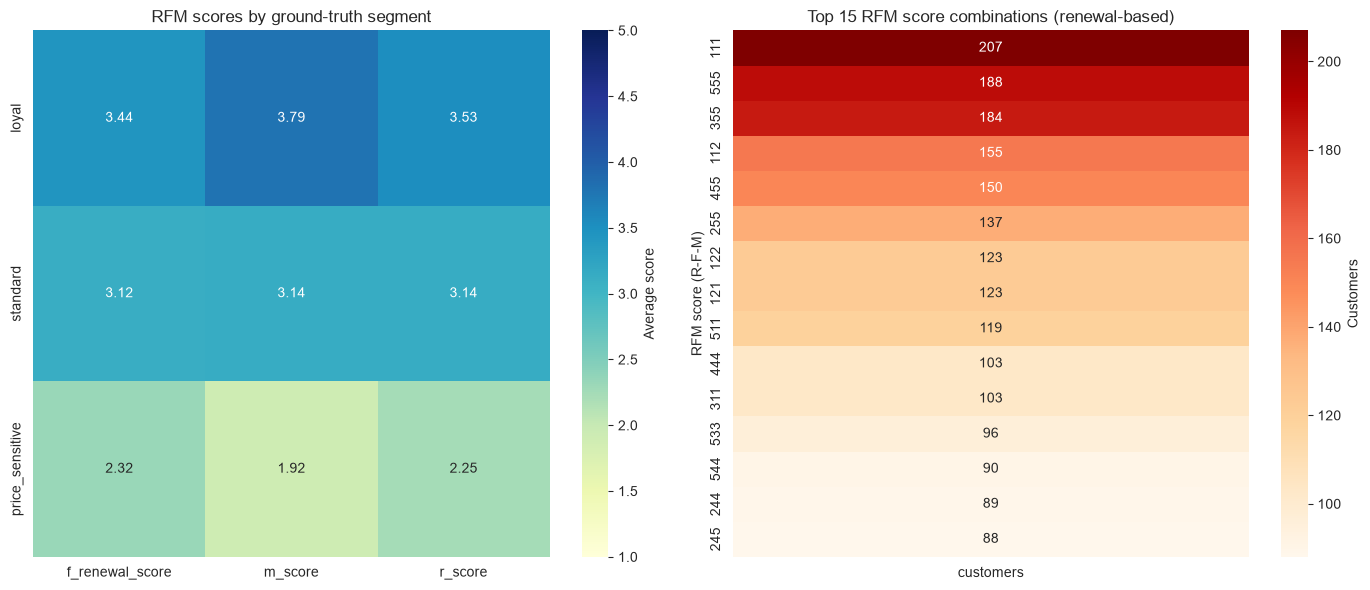

Saved: C:\Users\adebi\OneDrive\Desktop\DataScienceConsultingPortfolio\01_Portfolio-Projects\OkYeahInsight-Analytics\GuardianShield-Insurance\Engagement-2-Customer-Lifetime-Value\images\rfm_heatmaps.png


In [10]:
# ============================================
# RFM HEATMAP
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pivot_seg = rfm.pivot_table(
    index="segment",
    values=["r_score", "f_renewal_score", "m_score"],
    aggfunc="mean",
).loc[["loyal", "standard", "price_sensitive"]]

sns.heatmap(
    pivot_seg,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Average score"},
    ax=axes[0],
    vmin=1, vmax=5,
)
axes[0].set_title("RFM scores by ground-truth segment")
axes[0].set_ylabel("")

top_scores = (
    rfm["rfm_score_renewal"]
    .value_counts()
    .head(15)
    .to_frame("customers")
)

sns.heatmap(
    top_scores,
    annot=True,
    fmt="d",
    cmap="OrRd",
    cbar_kws={"label": "Customers"},
    ax=axes[1],
)
axes[1].set_title("Top 15 RFM score combinations (renewal-based)")
axes[1].set_ylabel("RFM score (R-F-M)")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "rfm_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {IMAGES_DIR / 'rfm_heatmaps.png'}")

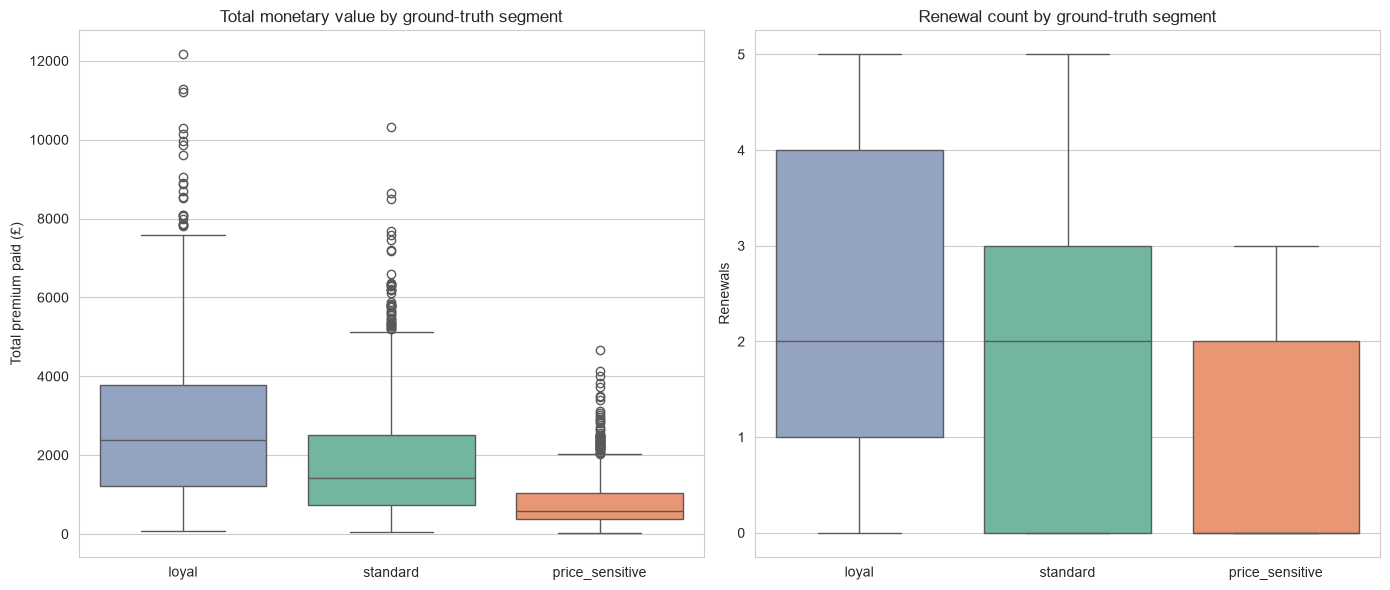

In [11]:
# ============================================
# MONETARY DISTRIBUTION BY SEGMENT
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=rfm,
    x="segment",
    y="monetary_total",
    ax=axes[0],
    hue="segment",
    palette="Set2",
    legend=False,
    order=["loyal", "standard", "price_sensitive"],
)
axes[0].set_title("Total monetary value by ground-truth segment")
axes[0].set_ylabel("Total premium paid (£)")
axes[0].set_xlabel("")

sns.boxplot(
    data=rfm,
    x="segment",
    y="frequency_renewal",
    ax=axes[1],
    hue="segment",
    palette="Set2",
    legend=False,
    order=["loyal", "standard", "price_sensitive"],
)
axes[1].set_title("Renewal count by ground-truth segment")
axes[1].set_ylabel("Renewals")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "rfm_segment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Business Insights

### 1. Payment cadence distorts raw frequency
The distribution of `frequency_tx` is visibly lumpy, driven by monthly vs. annual payment structures rather than customer loyalty. Using transaction count as "Frequency" would systematically inflate scores for monthly payers. **Renewal count removes this bias.**

### 2. RFM independently rediscovered all three segments
Average scores separate cleanly across all three dimensions:

| Segment | R score | F (renewal) score | M score |
|---------|---------|-------------------|---------|
| loyal | 3.53 | 3.44 | 3.79 |
| standard | 3.14 | 3.12 | 3.14 |
| price_sensitive | 2.25 | 2.32 | 1.92 |

Gaps: recency 1.28, renewal frequency 1.12, monetary 1.87. This validates both the data generation logic and the RFM methodology.

### 3. Recency separates segments most dramatically
Average days since last payment: **91 (loyal) → 205 (standard) → 499 (price_sensitive)**. Price-sensitive customers have been dormant for **5.5× longer** than loyal customers. Recency is the strongest early-warning signal for churn.

### 4. Monetary value is concentrated
The top quintile of customers by total premium accounts for a disproportionate share of revenue. A targeted retention programme for high-M customers would have outsized ROI compared to blanket campaigns.

### 5. Recommendation
Feed the RFM table into:
1. **BG/NBD + Gamma-Gamma** for probabilistic CLV prediction
2. **ML regression** (XGBoost/LightGBM) as a benchmark
3. **Power BI dashboard** for the executive audience

The segment structure is now clean enough that BG/NBD should differentiate well across all three groups.

In [12]:
# ============================================
# SAVE TO POSTGRES
# ============================================

rfm_out = rfm.reset_index()[[
    "customer_id",
    "recency_days",
    "frequency_tx",
    "frequency_renewal",
    "monetary_total",
    "r_score",
    "f_tx_score",
    "f_renewal_score",
    "m_score",
    "rfm_score_tx",
    "rfm_score_renewal",
    "segment",
]]

rfm_out.to_sql(
    name="rfm",
    con=engine,
    schema=DB_SCHEMA,
    if_exists="replace",
    index=False,
    method="multi",
    chunksize=1000,
)

with engine.connect() as conn:
    count = conn.execute(
        text(f"SELECT COUNT(*) FROM {DB_SCHEMA}.rfm;")
    ).scalar()

print(f"Wrote {count:,} rows to {DB_SCHEMA}.rfm")

Wrote 5,000 rows to clv.rfm


In [13]:
# ============================================
# VERIFY IN SQL
# ============================================

verify_query = f"""
SELECT
    segment,
    COUNT(*) AS customers,
    ROUND(AVG(recency_days)::numeric, 1) AS avg_recency,
    ROUND(AVG(frequency_renewal)::numeric, 2) AS avg_renewals,
    ROUND(AVG(monetary_total)::numeric, 2) AS avg_monetary,
    ROUND(AVG(r_score)::numeric, 2) AS avg_r_score,
    ROUND(AVG(f_renewal_score)::numeric, 2) AS avg_f_score,
    ROUND(AVG(m_score)::numeric, 2) AS avg_m_score
FROM {DB_SCHEMA}.rfm
GROUP BY segment
ORDER BY avg_monetary DESC;
"""

result = pd.read_sql(verify_query, engine)
print(result.to_string(index=False))

        segment  customers  avg_recency  avg_renewals  avg_monetary  avg_r_score  avg_f_score  avg_m_score
          loyal       1259         90.7          2.19       2751.58         3.53         3.44         3.79
       standard       2500        204.9          1.82       1762.38         3.14         3.12         3.14
price_sensitive       1241        498.7          0.90        783.38         2.25         2.32         1.92
